In [1]:
import os
path = r"C:\Users\Admin\Downloads\Main\Machine-Learning-Projects\Employees_Data_Detection\EmployeesData"
os.listdir(path)

['Change Status',
 'Contracts',
 'DUBAI INSURANCE COMPANY.pdf',
 'eVisa',
 'New Work Entry Permit - Employee',
 'output_images',
 'Passport',
 'Residence',
 'رسوم تاشيرة عمل.pdf',
 'رسوم تعديل وضع.pdf',
 'رسوم زيارة ثانية.pdf',
 'رسوم عقد عمل.pdf']

In [49]:
# Internal folder name
typeFolder = "Contracts"

# Map internal folder names to human-readable names
Folder_Names = {
    "Change Status": "Change_of_Status_Documents",
    "Residence": "Residence_Documents",
    "eVisa Tourism": "Tourism_Visa_Documents",
    "eVisa Employment": "Employment_Visa_Documents",
    "Employment Contract Full Work": "Full_Employment_Contracts",
    "Passport": "Passport_Documents"
}

In [50]:
import os
import fitz  # PyMuPDF

folder_name = Folder_Names.get(typeFolder, typeFolder)

# Full folder path
folder_path = os.path.join(path, typeFolder)

In [51]:
# This is a list comprehension in Python. It creates a list of .pdf files found in the folder folder_path.
files = [f for f in os.listdir(folder_path) if f.lower().endswith('.pdf')]
print(files)

['عقد عمل دوام كامل استقدام من الخارج.pdf']


In [52]:
# This is a list comprehension in Python. It creates a list of .pdf files found in the folder folder_path.
files = [f for f in os.listdir(folder_path) if f.lower().endswith('.pdf')]

# Open PDF file ( Indices relate to files number in the above list)
if files:
    pdf_path = os.path.join(folder_path, files[0])
    doc = fitz.open(pdf_path)
    text= doc[0].get_text()
    print(f"Reading from: {folder_name}")
    print(text)
else:
    print(f"No PDF files found in: {folder_path}")

Reading from: Contracts
Contract preview
مشاهدة العقد
EMPLOYMENT CONTRACT FULL WORK‌عقد عمل دوام كامل
Work permit (Recruiting a worker from outside the country)
)تصريح العمل (استقدام عامل من خارج الدولة
Work Style
Full Work
 دوام كامل
نمط العمل
Transaction Number
MB291046226AE
 
MB291046226AEرقم املعاملة
It is on Wednesday  Corresponding to  21/05/2025  in UAE
1. Establishment Name
NOOR ALMAMZAR MEDICAL CENTRE L.L.C
Establishment No
1233272
Represented by
ADHAM ALI BAKRI
Passport No
N016323869
Nationality
COMMONWEALTH OF DOMINICA
Title
owner
Emirate
Dubai
Telephone Number
0543726409
E-Mail
hr@nooralmamzar.com
Herein after referred to as the First Party / Employer in this Employment Contract
 
بين كل من 21/05/2025  املوافق االربعاء إنه في يوم
.اسم املنشأة1مركز نور املمزر الطبي ش.ذ.م.م
رقم املنشأة1233272
و يمثلها
ادهم على بكرى
رقم الجوازN016323869ا لجنسية
كمنولث دومينكا
الصفة
مالك
اإلمارة
دبي
رقم الهاتف0543726409البريد االلكترونيhr@nooralmamzar.com
ويشار الى ما ذكر في هذا البند بالطرف اأ

Convert PDF to Image and then use OCR to extract text from the image.

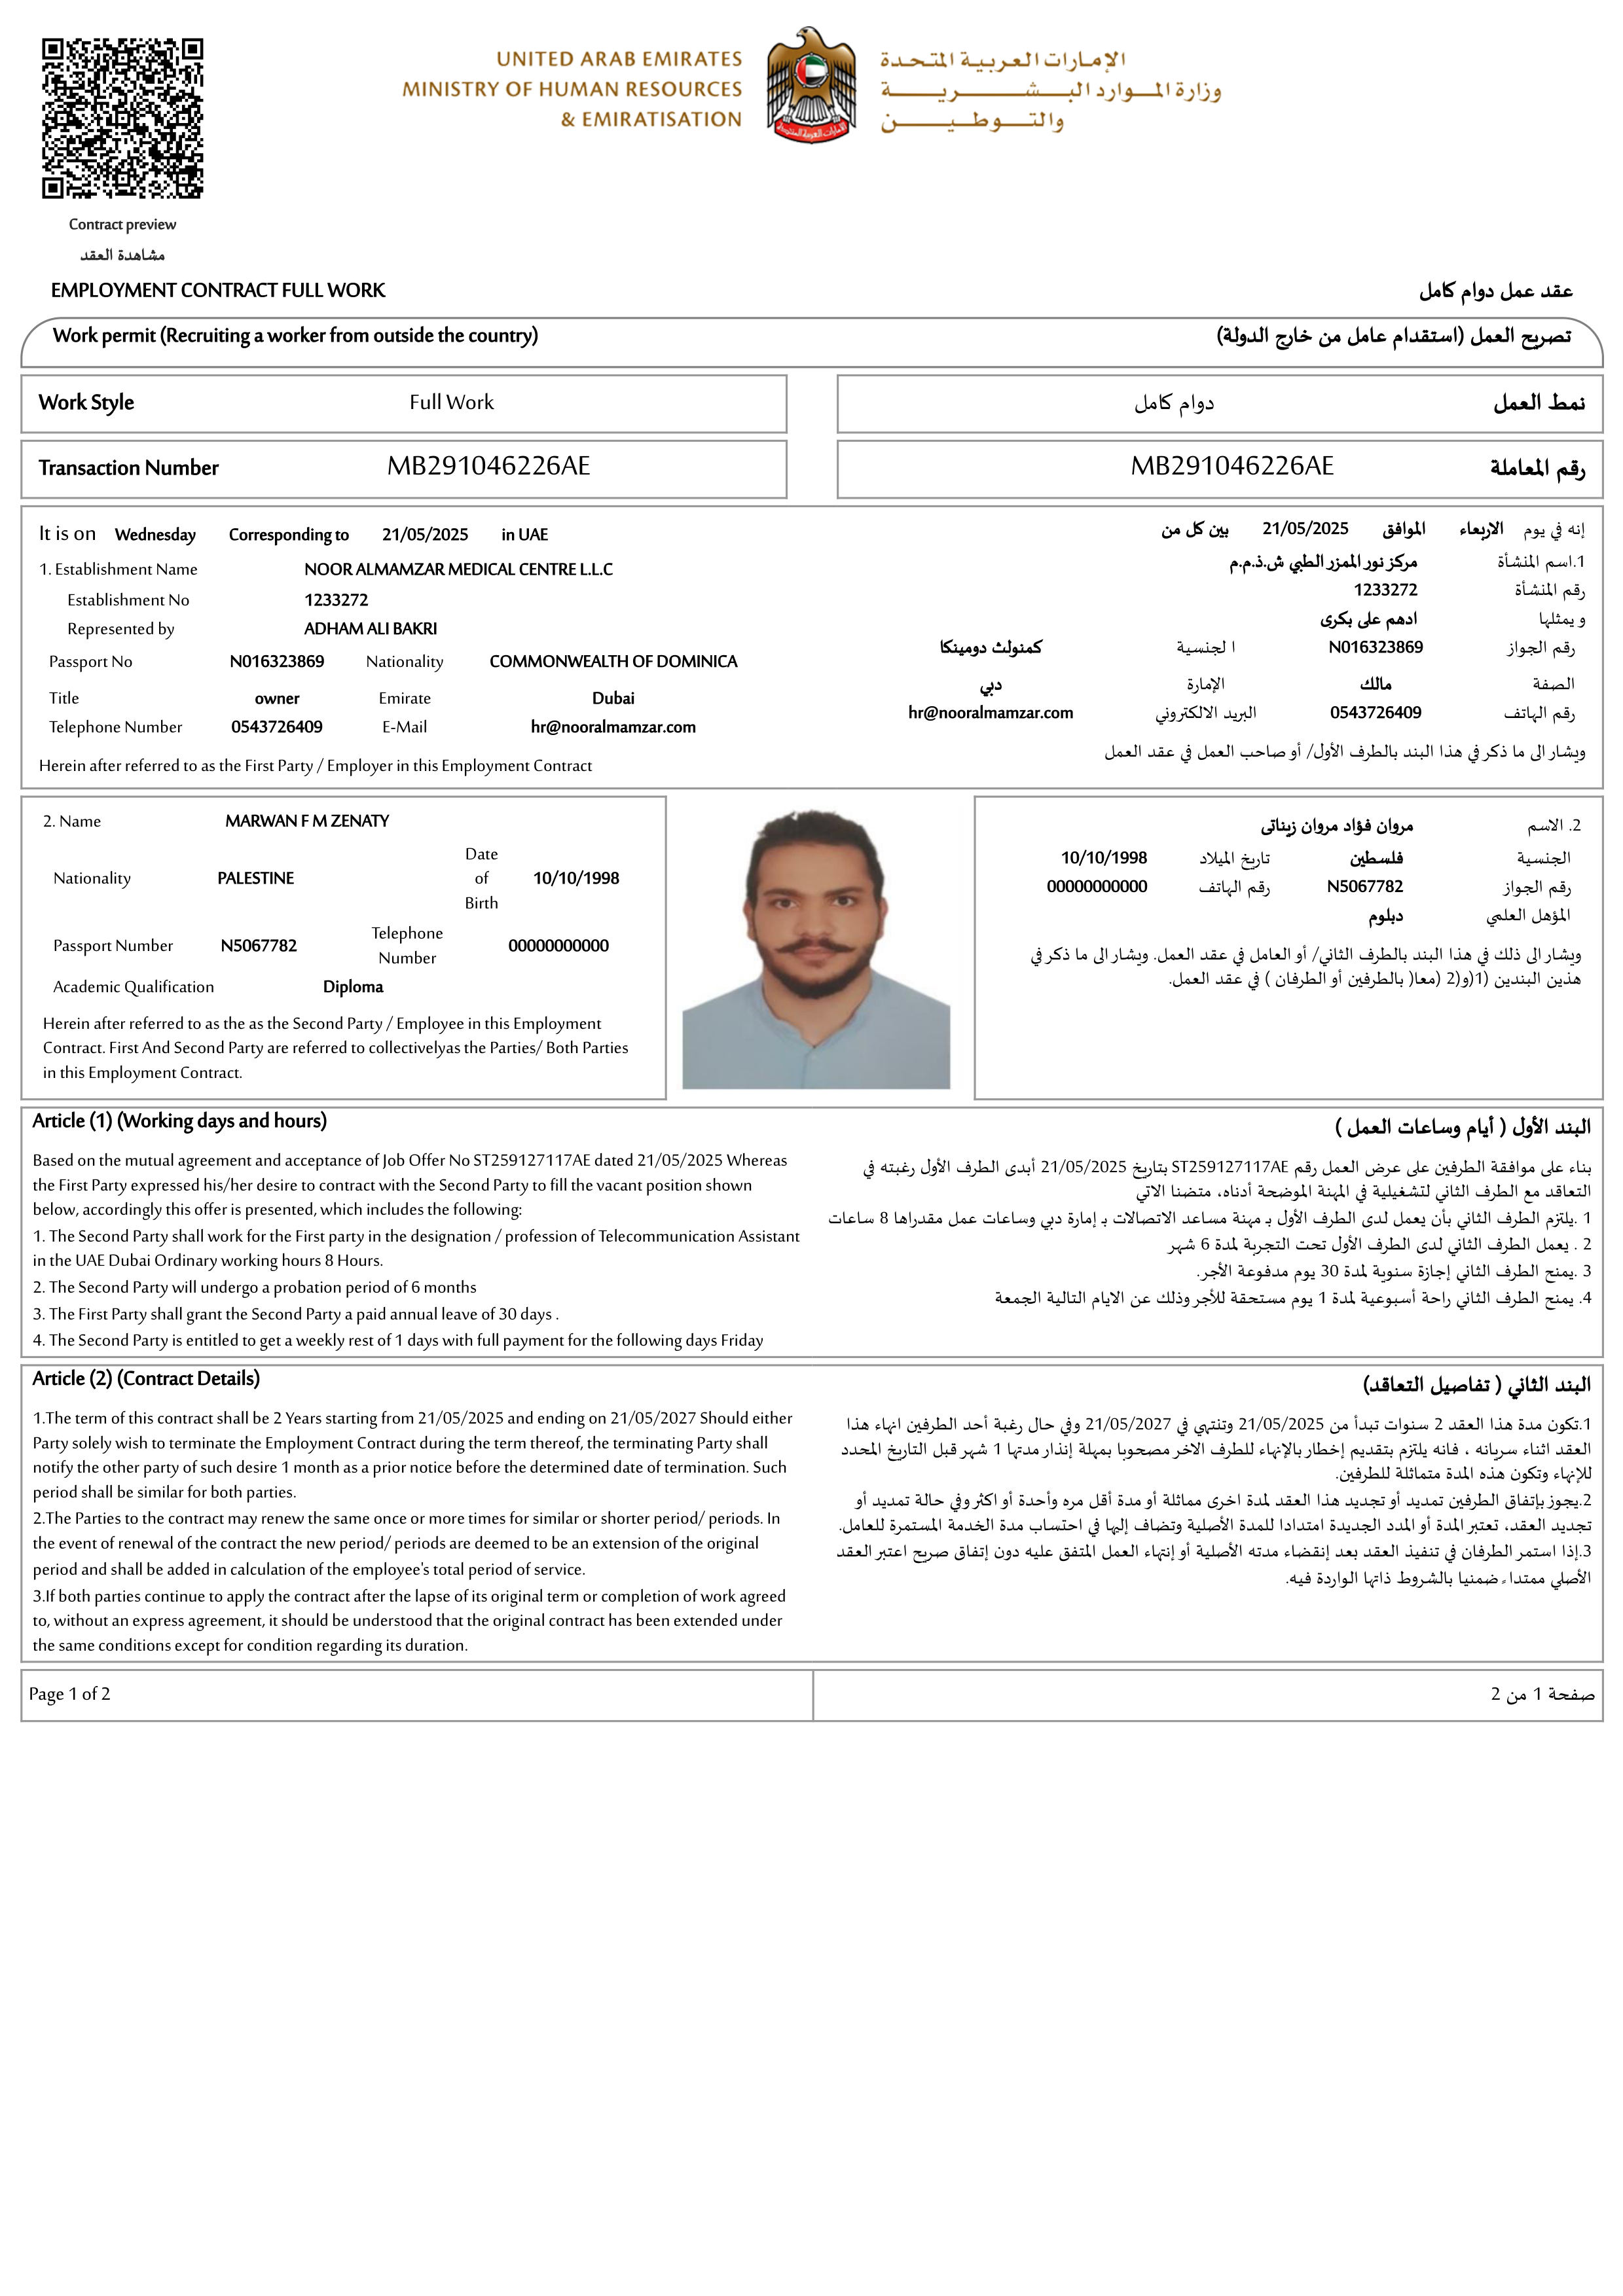

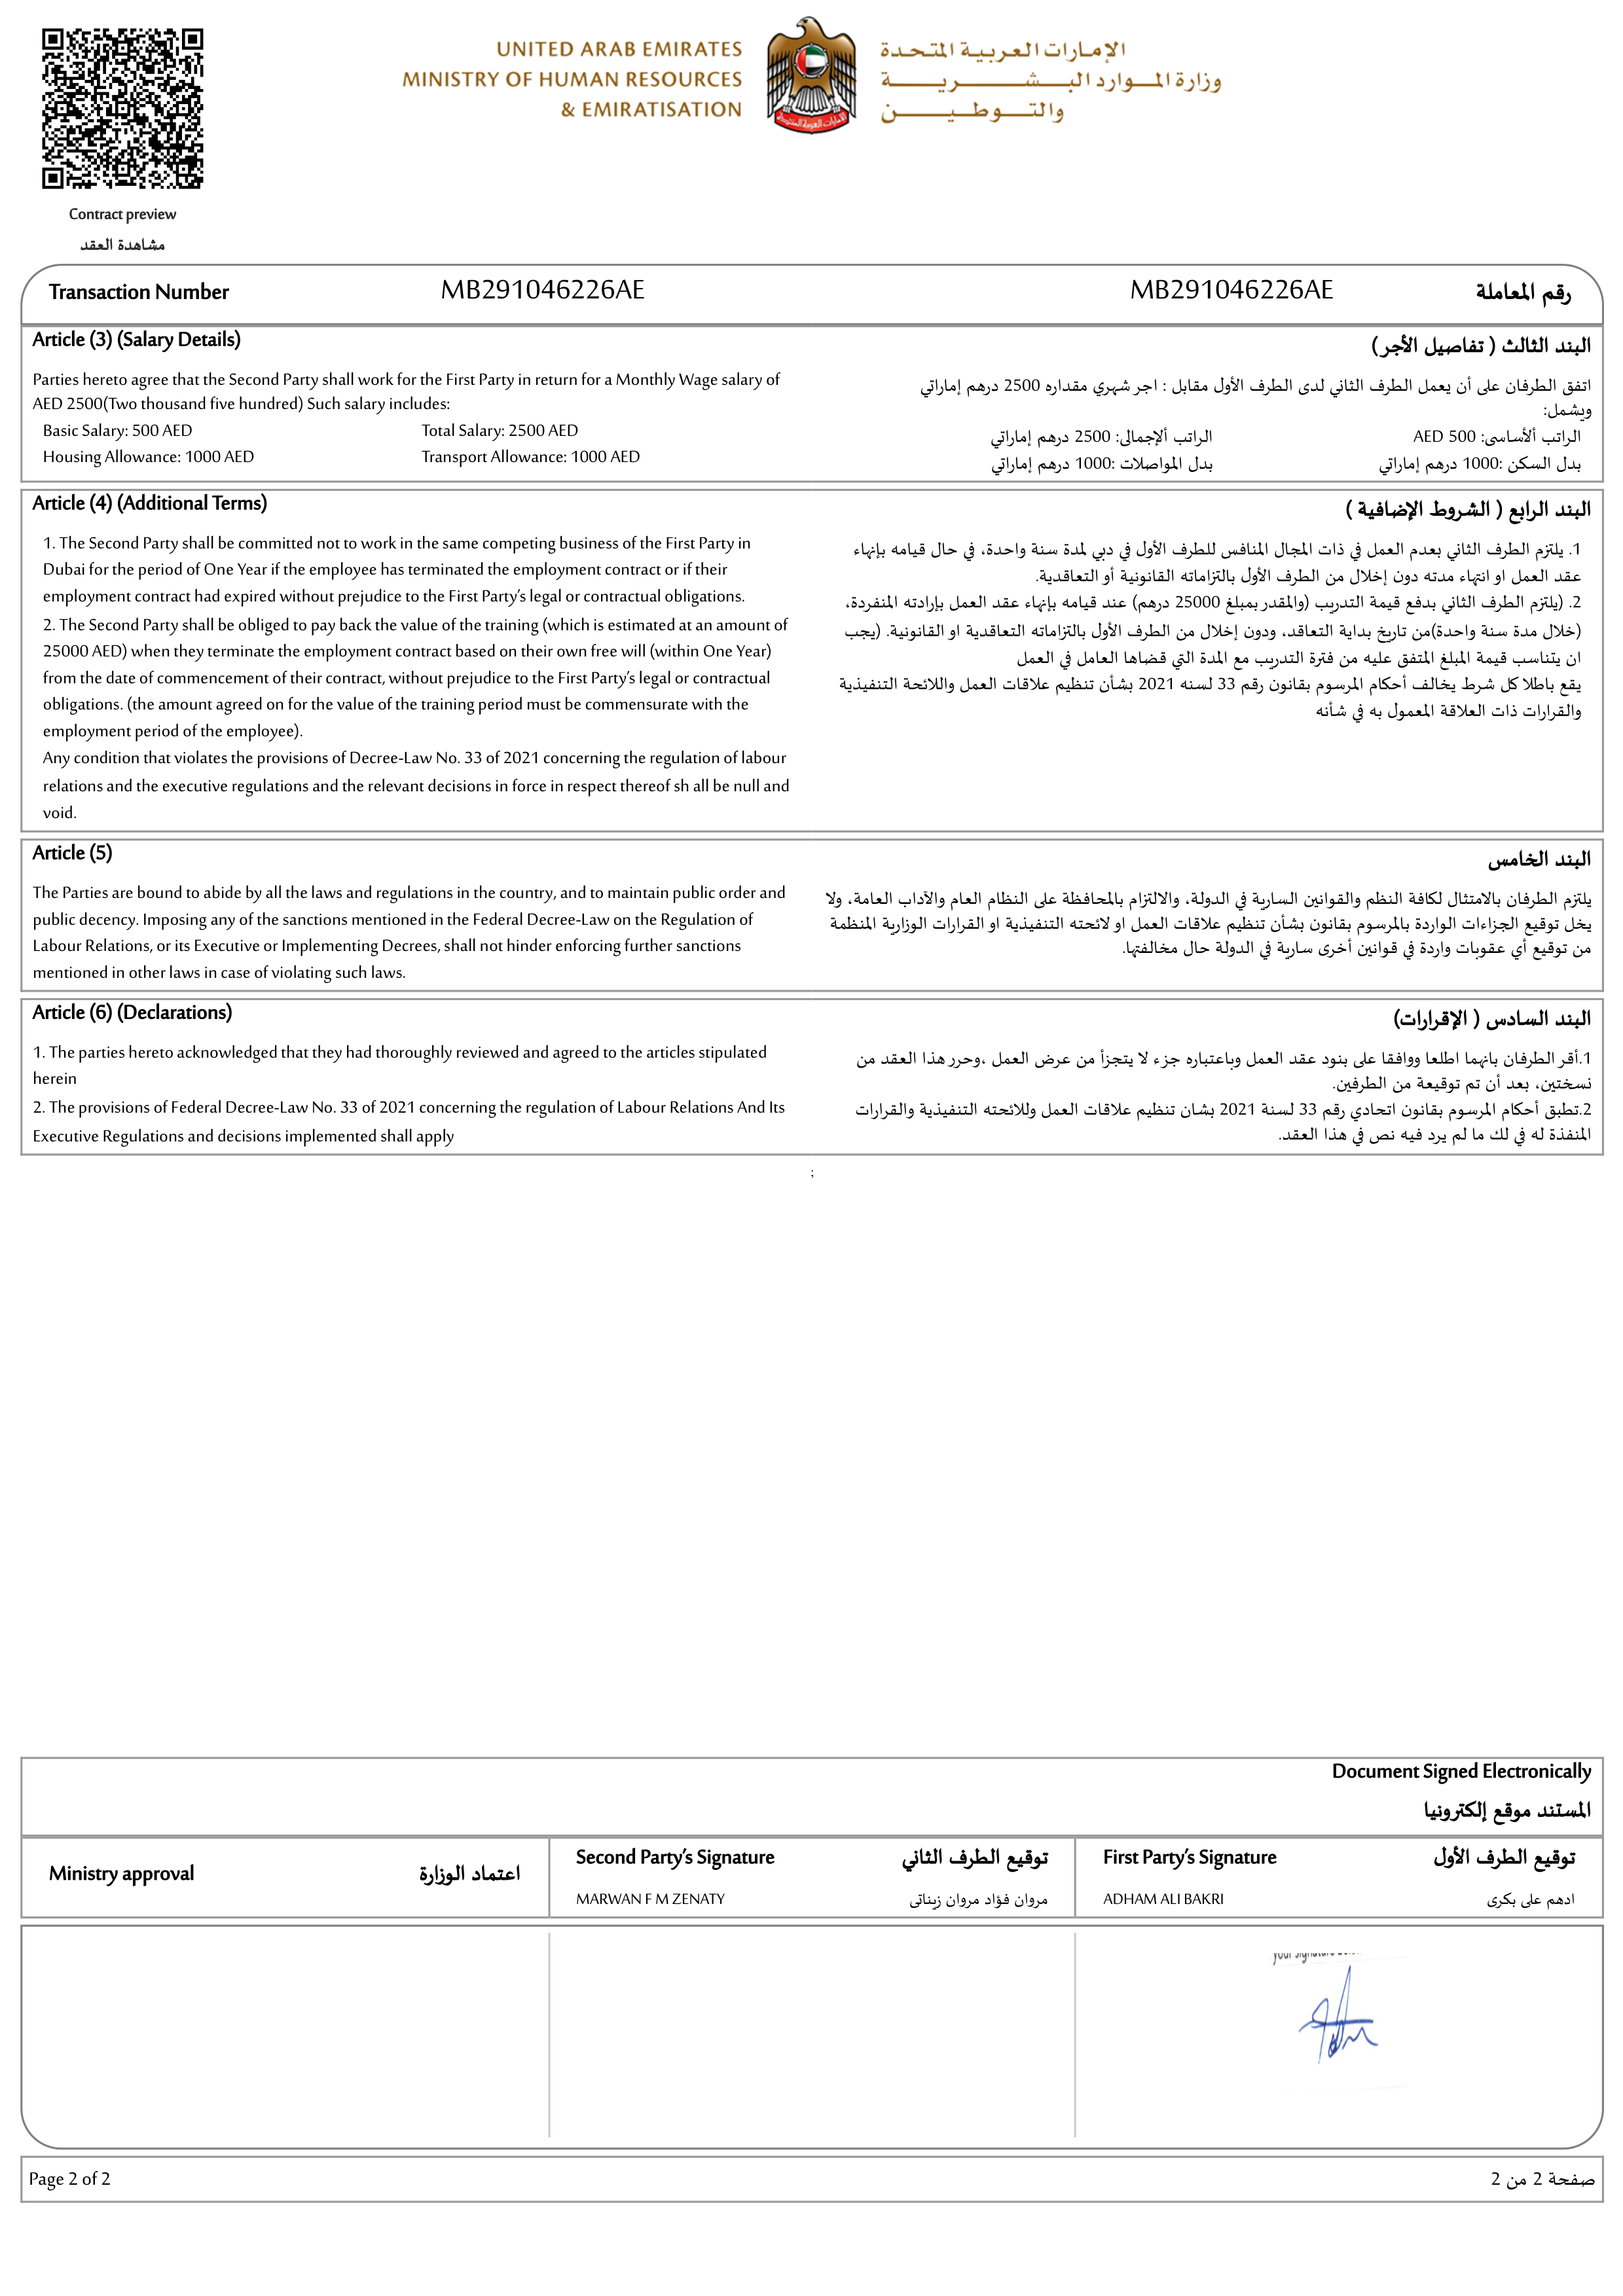

In [53]:
from PIL import Image
import io

import fitz  # PyMuPDF

# Convert each page of the PDF to an image and save/display
pdf_doc = fitz.open(pdf_path)
images = []
for i, page in enumerate(pdf_doc):
    pix = page.get_pixmap(dpi=300)
    img = Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB")
    images.append(img)
    # Optionally save the image
    img.save(f"page_{i+1}.png")
    # Optionally display the image in notebook
    display(img)

In [54]:
from pydantic import BaseModel, Field, ValidationError
from typing import Optional, Union, List
from enum import Enum


class PersonalInfo(str, Enum):
    CONTRACT = "EMPLOYMENT CONTRACT FULL WORK"
    TOURISM_VISA = "eVisa - Tourism"
    EMPLOYMENT_VISA = "eVisa - Employment"
    RESIDENCE = "Residence"
    CHANGE_STATUS = "Change Status"
    HEALTHCARE = "Healthcare Professional Registration Certificate"
    PASSPORT = "Passport"

class ContractData(BaseModel):
    work_style: Optional[str] = Field(None, description="Type of work (e.g., Full time, Part time, Temporary)")
    transaction_number: Optional[List[str]] = Field(None, description="Transaction number used by MOHRE")
    name: Optional[str] = Field(None, description="Full legal name of the employee")
    nationality: Optional[str] = Field(None, description="Nationality of the employee")
    passport_number: Optional[str] = Field(None, description="Passport number")
    date_of_birth: Optional[List[str]] = Field(None, description="Date of birth (YYYY-MM-DD or as found)")
    academic_qualification: Optional[str] = Field(None, description="Academic qualification")
    contract_start: Optional[str] = Field(None, description="Start date of the contract")
    contract_end: Optional[str] = Field(None, description="End date of the contract")


class VisaData(BaseModel):
    issue_date: Optional[str] = Field(None, description="Visa issue date (YYYY-MM-DD or as found) or similar format") 
    place_of_issue: Optional[str] = Field(None, description="Place of issue where the visa was issued and stamped by the Country government") 
    valid_until: Optional[str] = Field(None, description="Visa expiration date")
    uid_number: Optional[str] = Field(None, description="UID number (9 to 15 digits)")
    full_name: Optional[str] = Field(None, description="Full name of the visa holder")
    nationality: Optional[str] = Field(None, description="Nationality")
    place_of_birth: Optional[str] = Field(None, description="Place of birth")
    date_of_birth: Optional[str] = Field(None, description="Date of birth")
    passport_number: Optional[str] = Field(None, description="Passport number")
    profession: Optional[str] = Field(None, description="Profession listed")


class ResidenceData(BaseModel):
    id_number: Optional[str] = Field(None, description="ID number, may contain Arabic characters")
    passport_number: Optional[str] = Field(None, description="Passport number")
    name: Optional[str] = Field(None, description="Full name")
    profession: Optional[str] = Field(None, description="Profession")
    issue_date: Optional[str] = Field(None, description="Issue date")
    expiry_date: Optional[str] = Field(None, description="Expiration date")


class ChangeStatusData(BaseModel):
    uid_number: Optional[str] = Field(None, description="UID number")
    name: Optional[str] = Field(None, description="Full name")
    nationality: Optional[str] = Field(None, description="Nationality")
    profession: Optional[str] = Field(None, description="Profession")
    passport_number: Optional[str] = Field(None, description="Passport number")
    employer_name: Optional[str] = Field(None, description="Employer name")
    residence_stamping_deadline: Optional[str] = Field(None, description="Deadline for residence stamping")


class HealthcareRegistrationData(BaseModel):
    professional_name: Optional[str] = Field(None, description="Name of healthcare professional")
    dha_unique_id: Optional[str] = Field(None, description="DHA Unique Identifier")


class PassportData(BaseModel):
    passport_number: Optional[str] = Field(None, description="Passport number")
    name: Optional[str] = Field(None, description="Full name on passport")
    date_of_birth: Optional[str] = Field(None, description="Date of birth")
    date_of_issue: Optional[str] = Field(None, description="Date of issue")
    date_of_expiry: Optional[str] = Field(None, description="Date of expiry")
    profession: Optional[str] = Field(None, description="Profession listed")


# Unified Document Schema
class DocumentSchema(BaseModel):
    document_type: PersonalInfo = Field(..., description="The document type")
    contractDetails: Optional[List[ContractData]] = Field(None, description="Extracted contract details")
    visaDetails: Optional[List[VisaData]] = Field(None, description="Extracted visa details")
    residenceDetails: Optional[List[ResidenceData]] = Field(None, description="Extracted residence details")
    changeStatusDetails: Optional[List[ChangeStatusData]] = Field(None, description="Extracted change status details")
    healthcareDetails: Optional[List[HealthcareRegistrationData]] = Field(None, description="Extracted healthcare details")
    passportDetails: Optional[List[PassportData]] = Field(None, description="Extracted passport details")



##  Large Language Models (LLMs)

#### 1. QWEN OCR:
- Multilingual Support:
- Trained on large-scale data that includes Chinese, English, and other languages.
- Strong performance on mixed-language content (e.g., Chinese-English text).
- QWEN OCR is a proprietary model focused on text extraction.
- QWEN OCR is specifically designed for extracting text from images of documents, tables, and payslips.
- Qwen2-VL-2B-OCR is a fine-tuned variant of unsloth/Qwen2-VL-2B-Instruct, optimized specifically for Optical Character Recognition (OCR).

In [8]:
from transformers import AutoProcessor, AutoModelForImageTextToText

# Define the size dictionary with the required keys
# These values are based on the error message's suggested default if size is None
# You might need to adjust these based on the specific model documentation if available
processor_kwargs = {
    "size": {"shortest_edge": 56 * 56, "longest_edge": 28 * 28 * 1280}
}

# Load model from local path

model_path = r"C:\Users\Admin\Downloads\Main\Qwen2-VL-2B-OCR"

processor = AutoProcessor.from_pretrained(model_path, **processor_kwargs)
model = AutoModelForImageTextToText.from_pretrained(model_path)

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


In [59]:
import requests
import torch
import time
from torchvision import io
from typing import Dict


# Define the instruction
conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {
                "type": "text",
                "text": """
You are a document understanding system.

Given a scanned image of a document, your tasks are:
1. Automatically identify the document type. It must be one of the following:
   - EMPLOYMENT CONTRACT FULL WORK
   - eVisa - Tourism
   - eVisa - Employment
   - Residence
   - Change Status
   - Passport
   - Healthcare Professional Registration Certificate

2. Based on the identified document type, extract only the corresponding fields defined in the Unified Document Schema below.

### Unified Document Schema
Return your response strictly as a valid JSON object using the following schema:

{
  "document_type": "<Detected Document Type>",
  "contractDetails": [<ContractData>]       # Only include this if document_type is "EMPLOYMENT CONTRACT FULL WORK"
  "visaDetails": [<VisaData>]               # Only include this if document_type is "eVisa - Tourism" or "eVisa - Employment"
  "residenceDetails": [<ResidenceData>]     # Only include this if document_type is "Residence"
  "changeStatusDetails": [<ChangeStatusData>]  # Only include this if document_type is "Change Status"
  "healthcareDetails": [<HealthcareRegistrationData>]  # Only if document_type is "Healthcare Professional Registration Certificate"
  "passportDetails": [<PassportData>]       # Only include this if document_type is "Passport"
}

Only return the fields for the detected document type.
Do not include any unused keys or unrelated fields. Use `null` if a field is present but not readable.
Return valid JSON only.

"""
            }
        ]
    }
]

text_prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
inputs = processor(text=[text_prompt], images=[img], padding=True, return_tensors="pt")

start = time.time()
with torch.no_grad():
    output_ids = model.generate(**inputs, max_new_tokens=2048)
generated_text = processor.batch_decode(output_ids, skip_special_tokens=True)
elapsed = time.time() - start
print(f"Inference time: {elapsed:.2f} sec")

Inference time: 743.49 sec


In [58]:
print(generated_text)

system
You are a helpful assistant.
user

You are a document understanding system.

Given a scanned image of a document, your tasks are:
1. Automatically identify the document type. It must be one of the following:
   - EMPLOYMENT CONTRACT FULL WORK
   - eVisa - Tourism
   - eVisa - Employment
   - Residence
   - Change Status
   - Passport
   - Healthcare Professional Registration Certificate

2. Based on the identified document type, extract only the corresponding fields defined in the Unified Document Schema below.

### Unified Document Schema
Return your response strictly as a valid JSON object using the following schema:

{
  "document_type": "<Detected Document Type>",

  "contractDetails": [
    {
      "employer_name": "<Company or employer name>",
      "employee_name": "<Full name of employee>",
      "job_title": "<Job title>",
      "contract_start_date": "<YYYY-MM-DD>",
      "contract_end_date": "<YYYY-MM-DD or null if indefinite>",
      "salary_amount": "<numeric value>

In [24]:
q = schema_chain.invoke({"extractedData": generated_text})
q

NameError: name 'schema_chain' is not defined

In [25]:
parsed = DocumentSchema.parse_obj(generated_text)


C:\Users\Admin\AppData\Local\Temp\ipykernel_17884\1036919718.py:1: PydanticDeprecatedSince20: The `parse_obj` method is deprecated; use `model_validate` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  parsed = DocumentSchema.parse_obj(generated_text)


ValidationError: 1 validation error for DocumentSchema
  Input should be a valid dictionary or instance of DocumentSchema [type=model_type, input_value=['system\nYou are a helpf...sportDetails": null\n}'], input_type=list]
    For further information visit https://errors.pydantic.dev/2.11/v/model_type